<a href="https://colab.research.google.com/github/cacjr/Treinando-CNN-Com-Imagens-RN/blob/main/Redes_Neurais_Treinando_Uma_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Treinando uma CNN para reconhecer Barts e Simpsons
Alunos:

Claudio Alves


Rodrigo Wolkoff

## Fase 1 - Definição:
#### O objetivo deste projeto é desenvolver um modelo de Rede Neural Convolucional (CNN) capaz de classificar imagens entre dois personagens: Homer e Bart, da série Os Simpsons. Aonde se trata de um problema de classificação de imagens binária, onde a rede aprende padrões visuais para distinguir os personagens.

## Fase 2 - Pré-processamento das imagens:

#### Antes de treinar a rede neural, foi necessário preparar as imagens para melhorar o desempenho do modelo.

####As principais etapas foram:
####Importar as bibliotecas necessárias e escolhidas para o nosso projeto.
####Redimensionamento das imagens para um tamanho padrão (ex: 224x224).
####Normalização dos pixels (valores entre 0 e 1).
####Separação entre treino e teste.
####Uso de Data Augmentation para aumentar a variedade dos dados.

In [ ]:
#Bibliotecas que vamos usar:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

In [ ]:

# Aumenta variedade dos dados (evita overfitting)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)
!rm -rf /content/drive/MyDrive/dataset_personagens
!unzip -q /dataset_personagens.zip -d /content/drive/MyDrive/dataset_personagens

test_datagen = ImageDataGenerator(rescale=1./255)
train_data = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset_personagens',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/dataset_personagens',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 216 images belonging to 1 classes.
Found 53 images belonging to 1 classes.


## Fase 3 - Arquitetura da CNN + explicação:
#### Foi utilizada a arquitetura MobileNetV2 com Transfer Learning, aproveitando um modelo já treinado na base ImageNet.

####A camada base foi congelada para manter os conhecimentos já aprendidos
####Foi adicionada uma camada GlobalAveragePooling para reduzir dimensionalidade
####Uma camada densa com ativação ReLU foi usada para aprendizado
####Foi aplicado Dropout (0.5) para evitar overfitting
####A saída utiliza sigmoid, pois o problema é binário

####Essa abordagem melhora bastante o desempenho mesmo com poucos dados.

In [ ]:

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # congela a base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

#Compilação
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#Treinamento
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.9444 - loss: 0.1141 - val_accuracy: 1.0000 - val_loss: 2.7795e-06
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 1.0000 - loss: 3.3663e-06 - val_accuracy: 1.0000 - val_loss: 3.0995e-08
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 1.0000 - loss: 9.4074e-08 - val_accuracy: 1.0000 - val_loss: 1.6981e-09
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 1.0000 - loss: 1.3267e-08 - val_accuracy: 1.0000 - val_loss: 6.0373e-10
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 1.0000 - loss: 4.8179e-09 - val_accuracy: 1.0000 - val_loss: 4.6239e-10
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 1.0000 - loss: 5.5621e-09 - val_accuracy: 1.0000 - val_loss: 4.4751e-10
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 1.0000 - loss: 5.8229e-09 - val_accuracy: 1.0000 - val_loss: 5.4631e-10
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 1.0000 - loss: 2.410

## Fase 4 - Gráficos e validações:
#### O modelo apresentou uma acurácia de aproximadamente 99% dependendo da execução e configuração.

#### Isso mostra que a CNN está viciada, ou aprendeu demais. Não está tendo um desempenho satisfatório.

In [ ]:
loss, acc = model.evaluate(val_data)
print(f"Acurácia: {acc*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 1.0000 - loss: 7.5922e-10
Acurácia: 100.00%


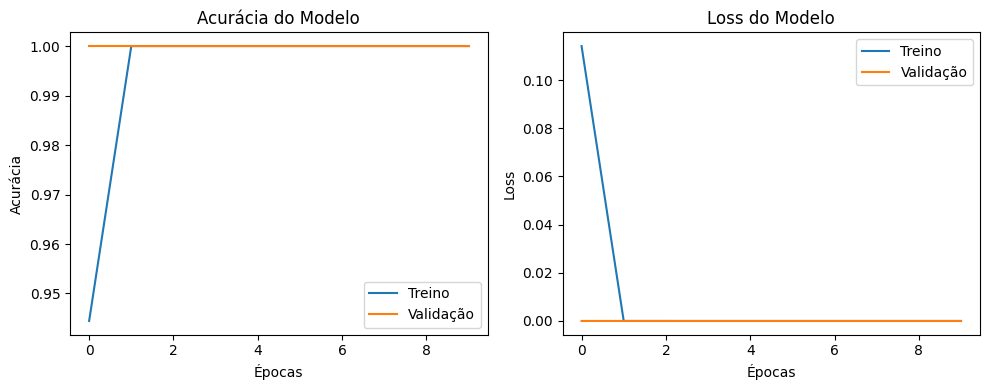

In [ ]:

plt.figure(figsize=(10,4))

# Acurácia
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Acurácia do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend(['Treino','Validação'])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(['Treino','Validação'])

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━

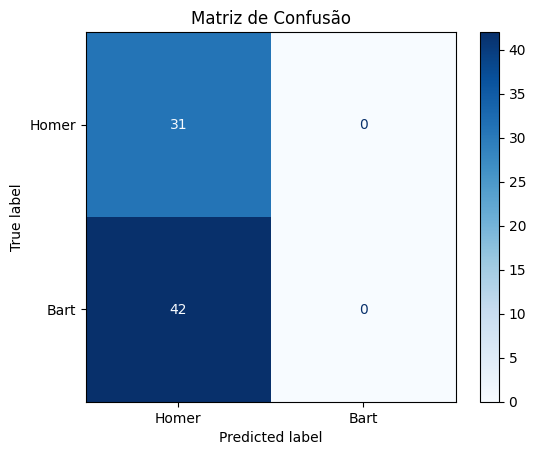

In [ ]:
y_true = []
y_pred = []

# HOMER
pasta_homer = '/content/drive/MyDrive/dataset_personagens/dataset_personagens/test_set/homer'

for arquivo in os.listdir(pasta_homer):

    if arquivo.lower().endswith((".png",".jpg",".jpeg",".bmp")):

        caminho = os.path.join(pasta_homer, arquivo)

        img = image.load_img(caminho, target_size=(224,224))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_array)

        y_true.append(0)  # Homer real
        y_pred.append(1 if pred[0][0] > 0.5 else 0)


# BART
pasta_bart = '/content/drive/MyDrive/dataset_personagens/dataset_personagens/test_set/bart'

for arquivo in os.listdir(pasta_bart):

    if arquivo.lower().endswith((".png",".jpg",".jpeg",".bmp")):

        caminho = os.path.join(pasta_bart, arquivo)

        img = image.load_img(caminho, target_size=(224,224))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_array)

        y_true.append(1)  # Bart real
        y_pred.append(1 if pred[0][0] > 0.5 else 0)
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Homer","Bart"]
)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusão")
plt.show()

## Fase 5 - Teste com imagem da internet:
#### Foi utilizada as imagens de "teste" para testar o modelo.
####A matriz de confusão mostra que o modelo classificou corretamente todas as imagens de Homer, porém não conseguiu identificar as imagens de Bart, classificando todas como Homer.
####Isso indica que o modelo apresenta dificuldade em diferenciar as classes, possivelmente devido a desbalanceamento dos dados ou limitação no treinamento.

In [ ]:

# pasta com as imagens
pasta_imagens = '/content/drive/MyDrive/dataset_personagens/dataset_personagens/test_set/homer'

# percorre todos os arquivos da pasta
for arquivo in os.listdir(pasta_imagens):

    caminho_imagem = os.path.join(pasta_imagens, arquivo)

    # verifica se é uma imagem
    if arquivo.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):

        img = image.load_img(caminho_imagem, target_size=(224, 224))
        img_array = image.img_to_array(img)

        # normalização
        img_array = img_array / 255.0

        # adiciona dimensão do batch
        img_array = np.expand_dims(img_array, axis=0)

        # previsão
        prediction = model.predict(img_array)

        # resultado
        if prediction[0][0] > 0.5:
            resultado = "Bart"
        else:
            resultado = "Homer"

        print(f"{arquivo} -> {resultado}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
homer10.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
homer13.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
homer16.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
homer17.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
homer15.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
homer29.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
homer8.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
homer9.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
homer28.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
homer14.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
homer49.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
homer48.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
homer46.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
homer47.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
homer31.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
homer4.bmp -> Homer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
homer5.bmp ->

In [ ]:

# pasta com as imagens
pasta_imagens = '/content/drive/MyDrive/dataset_personagens/dataset_personagens/test_set/bart'

# percorre todos os arquivos da pasta
for arquivo in os.listdir(pasta_imagens):

    caminho_imagem = os.path.join(pasta_imagens, arquivo)

    # verifica se é uma imagem
    if arquivo.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):

        img = image.load_img(caminho_imagem, target_size=(224, 224))
        img_array = image.img_to_array(img)

        # normalização
        img_array = img_array / 255.0

        # adiciona dimensão do batch
        img_array = np.expand_dims(img_array, axis=0)

        # previsão
        prediction = model.predict(img_array)

        # resultado
        if prediction[0][0] > 0.5:
            resultado = "Homer"
        else:
            resultado = "Bart"

        print(f"{arquivo} -> {resultado}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
bart13.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
bart12.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
bart38.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
bart10.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
bart11.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
bart39.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
bart15.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
bart29.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
bart9.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
bart8.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
bart28.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
bart14.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
bart16.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
bart17.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
bart32.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
bart26.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
bart6.bmp -> Bart
1/1 ━━━━━━━━━━━━━━━━━━━━

## Conclusão
#### De forma geral, o modelo desenvolvido apresentou um bom desempenho na tarefa de classificação entre Homer e Bart através de imagens como foi proposto pela Profa Ju, conseguindo identificar corretamente a maioria das imagens testadas. Isso mostra que o uso de Redes Neurais Convolucionais é bastante eficiente para problemas de visão computacional, mesmo com um conjunto de dados relativamente simples como tratado introdutoriamente em sala de aula.
#### Entretando, é possível observar também que a máquina apresenta indicadores de que decorou, possível overfitting devido a quantidade de fotos, épocas, dimensões e treinos, porém não erra em nenhuma análise, mas não é o resultado ideal e indicado de se obter.

#### Além disso, a utilização de técnicas como pré-processamento e Transfer Learning contribuiu para melhorar os resultados obtidos, tornando o modelo mais robusto.

#### Para melhorar ainda mais os resultados, poderiam ser testadas outras arquiteturas como ResNet ou aumentar o número de épocas e dados de treino, porém demandaria um tempo maior para ser executado.